### What is Exploratory Data Analysis?

Exploratory Data Analysis (EDA) is the initial and crucial phase of any data analysis project. It involves using statistical summaries and graphical representations to understand the main characteristics of a dataset. The goal of EDA is to uncover patterns, detect anomalies, test hypotheses, and check assumptions with the help of statistical and visualization techniques. It's a key step before formal modeling and machine learning.

### Key Goals of EDA:
- **Understand the Data**: Get a high-level overview of the dataset, including the number of rows and columns, data types, and missing values.
- **Identify Patterns**: Find relationships, trends, and correlations between different variables.
- **Detect Anomalies**: Discover outliers, errors, and inconsistencies that might affect later analysis.
- **Formulate Hypotheses**: Generate initial theories about the data that can be tested later.
- **Prepare for Modeling**: Clean, transform, and structure the data to make it suitable for machine learning algorithms.

### Essential Steps and Code for EDA

### Step 1: Data Loading and Initial Inspection
First, we need to load the data and get a general sense of what we're working with. We'll use the pandas and seaborn libraries in Python.

##### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

##### Read the data

In [2]:
location = "/Users/sahilnagpal/Library/Application Support/JetBrains/DataSpell2025.2/projects/workspace/data/dataset.csv"
titanic = pd.read_csv(location)

##### Data Information (.info()):
This method provides a concise summary of the DataFrame. It tells you the number of entries, the data type of each column (e.g., float64, object), and, critically, the number of non-null values. This is your first clue about missing data.

In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    object 
 3   sex       891 non-null    object 
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    object 
 8   fare      891 non-null    float64
 9   cabin     204 non-null    object 
 10  embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


##### Descriptive Statistics (.describe()):

This is a statistical summary for all numerical columns. It gives you measures like the count, mean, standard deviation, minimum, maximum, and quartiles (25%, 50%, 75%). This helps you quickly spot potential outliers or data that's not within an expected range. For example, if the maximum value is unexpectedly high, it might be an outlier.

In [4]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### Look into the data

In [5]:
titanic.head(5)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Step 2: Handling Missing Values 🤔
Missing data is a common and serious problem. Ignoring it can lead to biased or incorrect results. This step is about identifying and deciding how to address it.

Checking for Nulls: The .isnull().sum() method is a simple yet powerful way to count the number of missing values in each column. A result of 0 indicates no missing data in that column.

In [9]:
titanic.isnull().sum()

survived      0
pclass        0
name          0
sex           0
age         177
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      2
Age_mean      0
dtype: int64

#### Deciding on a Strategy: There are several ways to handle missing data, and the choice depends on the specific context:
- **Dropping Rows/Columns**: If a column has too many missing values (e.g., >50%), it might be better to drop it. Similarly, if a row is missing a critical value, you might drop that row.
- **Imputation**: This involves filling in the missing values. You can replace them with the mean, median, or mode of the column. For categorical data, you might use the mode or a specific placeholder.
- **Modeling**: In more advanced cases, you can use machine learning models to predict and fill in the missing values.

In [7]:
titanic['Age_mean'] =  titanic['age'].fillna(titanic['age'].mean())

In [8]:
titanic

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,Age_mean
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.000000
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.000000
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.000000
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.000000
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.000000
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.000000
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,29.699118
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.000000


#### Step 3: Univariate Analysis 📈
Univariate analysis is the simplest form of data analysis, focusing on a single variable at a time. This helps you understand the distribution, central tendency, and spread of each feature independently.

#### Numerical Variables:

- **Histograms**: A histogram divides the data into bins and counts the number of observations in each bin. This visualizes the distribution shape. Is it normal (bell-shaped), skewed, or uniform?
- **Box Plots**: A box plot provides a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. It's excellent for identifying outliers, which are data points that fall far outside the main distribution.

#### Step 4: Bivariate and Multivariate Analysis 🧩
This is where you explore the relationships between two or more variables. This step is crucial for uncovering correlations and dependencies that can inform your modeling.

- **Scatter Plots**: A scatter plot is a classic way to visualize the relationship between two numerical variables. Each point represents an observation, and its position is determined by its values on the x and y axes.

- **Pair Plots**: This is an extension of scatter plots. It creates a grid of plots showing all pairwise relationships between numerical variables in the dataset. By coloring points by a categorical variable (e.g., species), you can see how different groups behave.

#### Correlation Matrix and Heatmap:

- **Correlation Matrix**: This is a table of correlation coefficients between variables. The value ranges from -1 to 1, where 1 means a perfect positive correlation, -1 means a perfect negative correlation, and 0 means no linear correlation.

- **Heatmap**: A heatmap is a color-coded representation of the correlation matrix, making it easy to visually identify strong relationships. Darker colors might indicate a strong positive or negative correlation.

#### Feature Engineering

Let's do little bit of processing to make some different variables that might be more interesting to plot.

##### Custom Methods

In [10]:
def woman_child_or_man(passenger):
    age, sex = passenger
    if age < 16:
        return "child"
    else:
        return dict(male="man", female="woman")[sex]

In [11]:
titanic["class"] = titanic.pclass.map({1: "First", 2: "Second", 3: "Third"})
titanic["who"] = titanic[["age", "sex"]].apply(woman_child_or_man, axis=1)
titanic["adult_male"] = titanic.who == "man"
titanic["deck"] = titanic.cabin.str[0].map(lambda s: np.nan if s == "T" else s)
titanic["embark_town"] = titanic.embarked.map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
titanic["alive"] = titanic.survived.map({0: "no", 1: "yes"})
titanic["alone"] = ~(titanic.parch + titanic.sibsp).astype(bool)
titanic = titanic.drop(["name", "ticket", "cabin"], axis=1)

In [12]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,Age_mean,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,22.000000,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,38.000000,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,26.000000,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,35.000000,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,35.000000,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,27.000000,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,19.000000,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,29.699118,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,26.000000,First,man,True,C,Cherbourg,yes,True


#### More features
person-type --> if 0-15 'Child' , if 16-50 'Aduld' >50 old'

fair-type --> mean of fare + 60 fair-type 100 --lower 100-400 middle > 400 'higher'


##### Setting up seaborn design palette

In [13]:
pal = dict(man="#4682B4", woman="#CD5C5C", child="#2E8B57", male="#6495ED", female="#F08080")

#### Who were the Titanic passengers?
Before getting to the main question (who survived), let's take a look at the dataset to get a sense for how the observations are distributed into the different levels of our factors of interest.

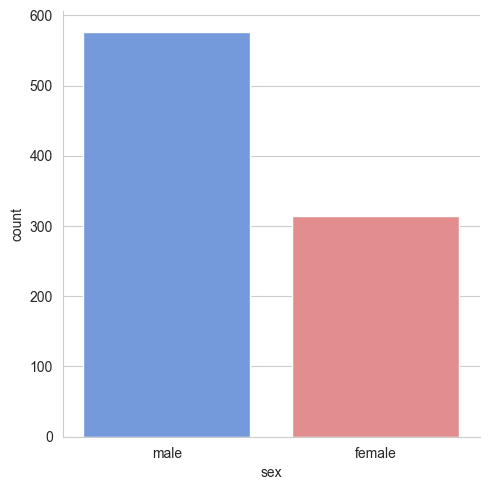

In [14]:
# How many men, women, and children are in our sample?
sns.catplot(x="sex", data=titanic, kind="count", palette=pal);

##### Then we can look at how this is distributed into the three classes.

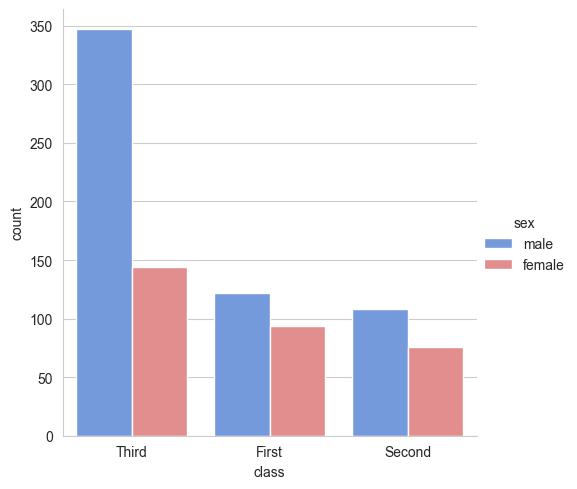

In [15]:
sns.catplot(x="class", data=titanic, hue="sex", palette=pal, kind="count");

##### We also have a separate classification that splits off children (recall, this is going to be relevant because of the "women and children first" policy followed during the evacuation).

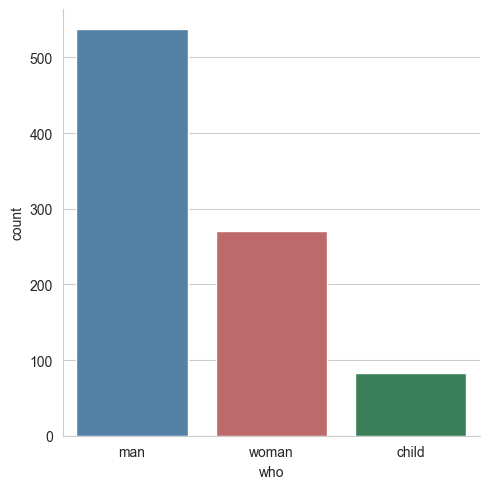

In [16]:
sns.catplot(x="who", data=titanic, palette=pal, kind="count");

##### Next let's look at the distribution of ages within the groups we defined above.

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


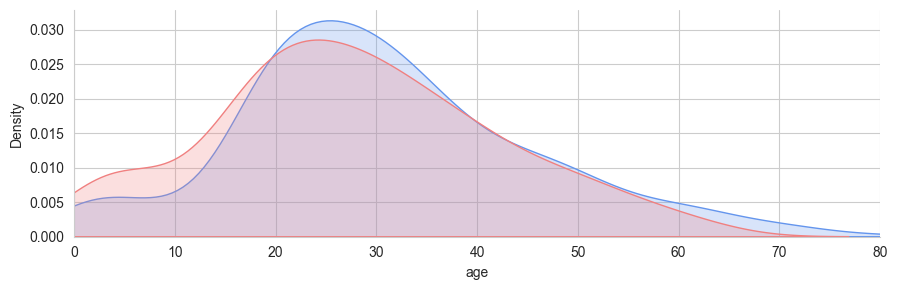

In [17]:
fg = sns.FacetGrid(titanic, hue="sex", aspect=3, palette=pal)
fg.map(sns.kdeplot, "age", shade=True)
fg.set(xlim=(0, 80));

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


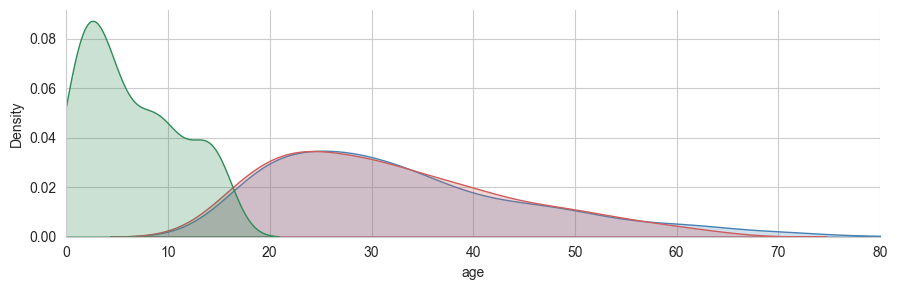

In [18]:
fg = sns.FacetGrid(titanic, hue="who", aspect=3, palette=pal)
fg.map(sns.kdeplot, "age", shade=True)
fg.set(xlim=(0, 80));

##### How many first, second, and third class passengers are in our sample?
Although have some information about the distribution into classes from the sex plots, let's directly visualize it an then see how the classes break down by age.

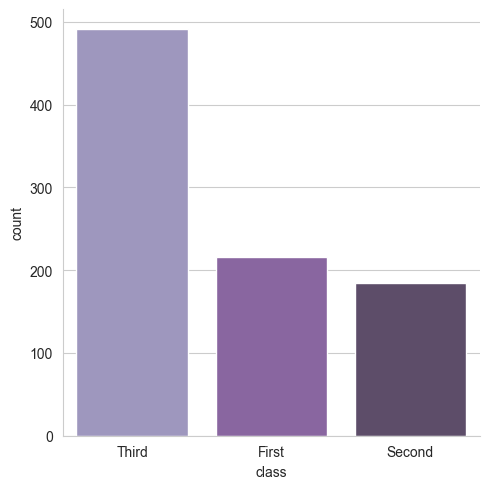

In [19]:
sns.catplot(x="class", data=titanic, palette="BuPu_d",kind="count");

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


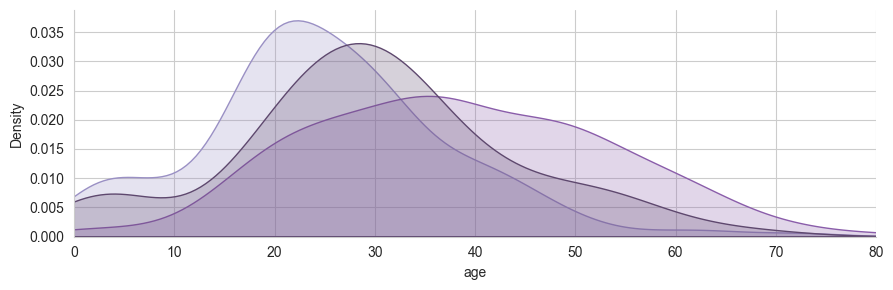

In [20]:
fg = sns.FacetGrid(titanic, hue="class", aspect=3, palette="BuPu_d")
fg.map(sns.kdeplot, "age", shade=True)
fg.set(xlim=(0, 80));

##### Where were our passenger's cabins?
We also have information about what deck each passgener's cabin was on, which may be relevant.

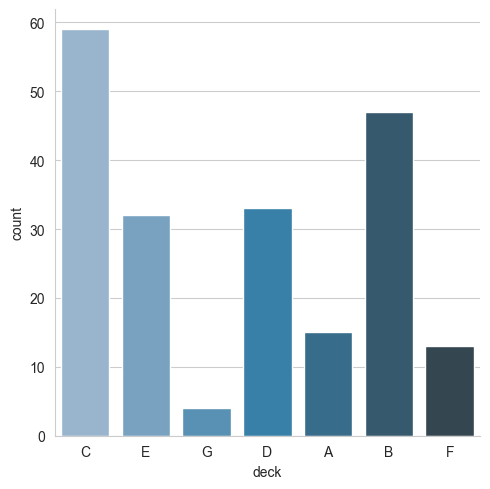

In [21]:
sns.catplot(x="deck", data=titanic, palette="PuBu_d",kind="count");

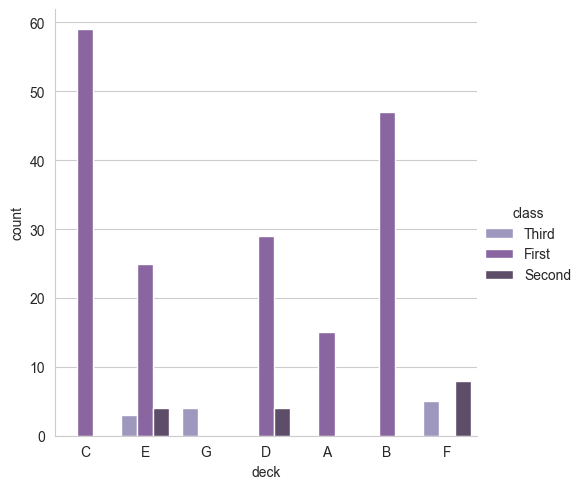

In [22]:
sns.catplot(x="deck", hue="class", data=titanic, palette="BuPu_d",kind="count");

##### How much did they pay for their tickets?
Since we have data about fares, let's see how those broke down by classes.

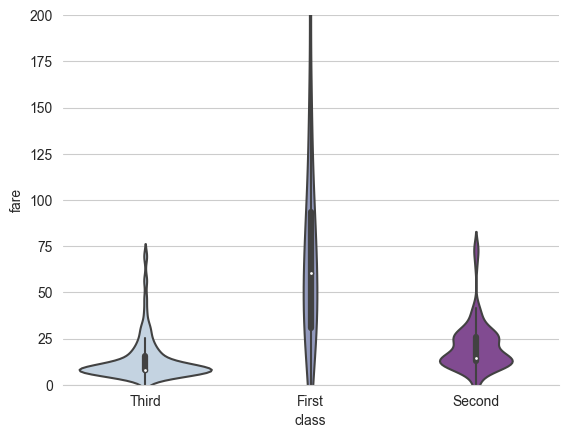

In [23]:
sns.violinplot(x=titanic["class"], y=titanic["fare"], palette="BuPu").set_ylim(0, 200)
sns.despine(left=True)

##### What made people survive the sinking?

Now that we have a feel for the characteristics of our sample, let's get down to the main question and ask what factors seem to predict whether our passengers survived. But first, one more count plot just to see how many of our passengers perished in the sinking.

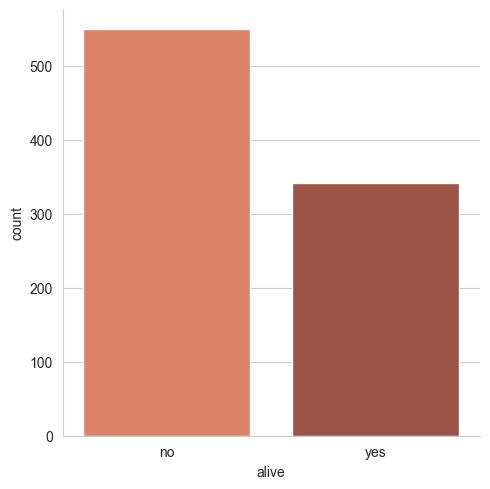

In [24]:
sns.catplot(x="alive", data=titanic, palette="OrRd_d",kind="count");

##### What classes had the survivors traveled in?
It's part of popular lore that the third-class (or steerage) passengers fared much more poorly than their wealthier shipmates. Is this borne out in the data?

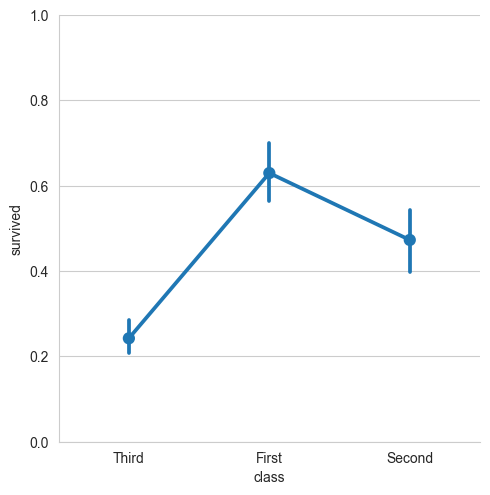

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(x="class", y="survived", data=titanic, kind="point")
g.set(ylim=(0, 1))
plt.show()

##### Did it matter what passengers paid, or where they stayed?
We know that class matters, but we can also use the fare variable as a proxy for a contiuous measure of wealth.

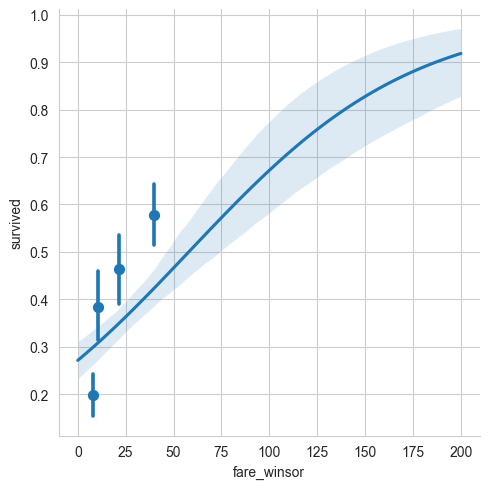

In [26]:
titanic["fare_winsor"] = titanic.fare.map(lambda f: min(f, 200))
sns.lmplot(x="fare_winsor", y="survived", data=titanic, x_bins=4, logistic=True, truncate=True);